In [2]:
import sys
print(sys.executable)

/home/moi/miniconda3/envs/hls4ml-tutorial/bin/python3.10


In [3]:
import sys
!{sys.executable} -m pip install pyserial scipy

  Using cached pyserial-3.5-py2.py3-none-any.whl.metadata (1.6 kB)
Using cached pyserial-3.5-py2.py3-none-any.whl (90 kB)


In [5]:
import time, json, threading, queue
from pathlib import Path
import numpy as np
from scipy.stats import kurtosis, skew
import serial

WARMUP_DURATION   = 30 * 60
COLLECT_DURATION  = 90 * 60
SAMPLING_RATE     = 10_000
WINDOW_SIZE       = 1024
WINDOW_OVERLAP    = 512
WINDOW_STEP       = WINDOW_SIZE - WINDOW_OVERLAP
OUTPUT_DIR        = Path(".")
FEATURES_FILE     = OUTPUT_DIR / "features.npy"
META_FILE         = OUTPUT_DIR / "collection_meta.json"

In [6]:
FEATURE_NAMES = [
    "mean", "std", "rms", "max", "min",
    "peak_to_peak", "skewness", "kurtosis",
    "crest_factor", "shape_factor", "impulse_factor",
    "freq_dominant", "spectral_energy", "spectral_entropy",
]

def extract_features(window: np.ndarray, fs: int = SAMPLING_RATE) -> np.ndarray:
    n = len(window)
    eps = 1e-10

    mean_val    = np.mean(window)
    std_val     = np.std(window)
    rms_val     = np.sqrt(np.mean(window ** 2))
    max_val     = np.max(np.abs(window))
    min_val     = np.min(np.abs(window))
    p2p_val     = np.ptp(window)
    skew_val    = float(skew(window))
    kurt_val    = float(kurtosis(window))
    crest_val   = max_val / (rms_val + eps)
    mean_abs    = np.mean(np.abs(window))
    shape_val   = rms_val  / (mean_abs + eps)
    impulse_val = max_val  / (mean_abs + eps)

    fft_mag     = np.abs(np.fft.rfft(window))
    freqs       = np.fft.rfftfreq(n, d=1.0 / fs)
    freq_dom    = freqs[np.argmax(fft_mag)]
    spec_energy = np.sum(fft_mag ** 2)
    psd_norm    = fft_mag ** 2 / (spec_energy + eps)
    spec_entropy = -np.sum(psd_norm * np.log2(psd_norm + eps))

    return np.array([
        mean_val, std_val, rms_val, max_val, min_val,
        p2p_val, skew_val, kurt_val, crest_val, shape_val,
        impulse_val, freq_dom, spec_energy, spec_entropy,
    ], dtype=np.float32)

In [7]:
def reader_thread(port, baud, data_queue, stop_event):
    try:
        ser = serial.Serial(port, baud, timeout=1.0)
        print(f"[Capteur] Connecté sur {port} @ {baud} baud")
        while not stop_event.is_set():
            line = ser.readline().decode("utf-8", errors="ignore").strip()
            if not line:
                continue
            try:
                value = float(line.split(",")[0])
                data_queue.put(value)
            except ValueError:
                pass
        ser.close()
    except serial.SerialException as e:
        print(f"[Capteur] Erreur série : {e}")
        stop_event.set()

def simulate_reader(data_queue, stop_event, fs=SAMPLING_RATE):
    print("[Simulation] Signal synthétique : 120 Hz + bruit")
    t = 0
    dt = 1.0 / fs
    while not stop_event.is_set():
        value = 0.5 * np.sin(2 * np.pi * 120 * t) + 0.05 * np.random.randn()
        data_queue.put(float(value))
        t += dt
        if int(t * fs) % 100 == 0:
            time.sleep(100 / fs)

In [8]:
def collect(port=None, baud=115200, simulate=False):
    data_queue    = queue.Queue(maxsize=100_000)
    stop_event    = threading.Event()
    buffer        = []
    features_list = []

    if simulate:
        t = threading.Thread(target=simulate_reader, args=(data_queue, stop_event), daemon=True)
    else:
        t = threading.Thread(target=reader_thread,   args=(port, baud, data_queue, stop_event), daemon=True)
    t.start()

    start_time = time.time()

    # ── Phase rodage ──────────────────────────────────────────────────────────
    print(f"[Phase 1] Rodage ({WARMUP_DURATION//60} min) — données ignorées...")
    while time.time() - start_time < WARMUP_DURATION:
        remaining = WARMUP_DURATION - (time.time() - start_time)
        print(f"\r  {int(remaining//60):02d}:{int(remaining%60):02d} restantes   ", end="", flush=True)
        while not data_queue.empty():
            data_queue.get_nowait()
        time.sleep(5)
    print("\n[Phase 1] Rodage terminé ✓")

    # ── Phase collecte ────────────────────────────────────────────────────────
    collect_start = time.time()
    print(f"[Phase 2] Collecte ({COLLECT_DURATION//60} min) — extraction des features...")

    while time.time() - collect_start < COLLECT_DURATION:
        while not data_queue.empty() and len(buffer) < WINDOW_SIZE * 4:
            buffer.append(data_queue.get_nowait())

        while len(buffer) >= WINDOW_SIZE:
            window = np.array(buffer[:WINDOW_SIZE], dtype=np.float32)
            buffer = buffer[WINDOW_STEP:]
            features_list.append(extract_features(window))

        remaining = COLLECT_DURATION - (time.time() - collect_start)
        print(f"\r  {int(remaining//60):02d}:{int(remaining%60):02d} restantes "
              f"| {len(features_list)} fenêtres   ", end="", flush=True)
        time.sleep(0.1)

    stop_event.set()
    print(f"\n[Phase 2] Terminé ✓ — {len(features_list)} fenêtres extraites")

    if not features_list:
        print("[ERREUR] Aucune feature extraite.")
        return

    # ── Sauvegarde ────────────────────────────────────────────────────────────
    features_array = np.stack(features_list, axis=0)
    np.save(FEATURES_FILE, features_array)
    print(f"[Sauvegarde] {FEATURES_FILE}  shape={features_array.shape}")

    meta = {
        "n_windows"       : int(features_array.shape[0]),
        "n_features"      : int(features_array.shape[1]),
        "feature_names"   : FEATURE_NAMES,
        "window_size"     : WINDOW_SIZE,
        "window_step"     : WINDOW_STEP,
        "sampling_rate_hz": SAMPLING_RATE,
        "collected_at"    : time.strftime("%Y-%m-%dT%H:%M:%S"),
        "features_mean"   : features_array.mean(axis=0).tolist(),
        "features_std"    : features_array.std(axis=0).tolist(),
    }
    with open(META_FILE, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[Sauvegarde] {META_FILE}")

    print("\n── Aperçu des moyennes ──")
    for name, val in zip(FEATURE_NAMES, features_array.mean(axis=0)):
        print(f"  {name:<20} : {val:.4f}")

# ── Lancement ─────────────────────────────────────────────────────────────────
collect(simulate=True)       # ← test sans capteur
# collect(port="/dev/ttyUSB0", baud=115200)   # ← avec capteur réel

[Simulation] Signal synthétique : 120 Hz + bruit
[Phase 1] Rodage (30 min) — données ignorées...
  00:03 restantes   
[Phase 1] Rodage terminé ✓
[Phase 2] Collecte (90 min) — extraction des features...
  00:00 restantes | 89565 fenêtres   
[Phase 2] Terminé ✓ — 89565 fenêtres extraites
[Sauvegarde] features.npy  shape=(89565, 14)
[Sauvegarde] collection_meta.json

── Aperçu des moyennes ──
  mean                 : -0.0000
  std                  : 0.3570
  rms                  : 0.3571
  max                  : 0.6321
  min                  : 0.0008
  peak_to_peak         : 1.2409
  skewness             : 0.0000
  kurtosis             : -1.4407
  crest_factor         : 1.7705
  shape_factor         : 1.1162
  impulse_factor       : 1.9761
  freq_dominant        : 117.0936
  spectral_energy      : 66876.1328
  spectral_entropy     : 1.7563


In [9]:
import json
import numpy as np
from pathlib import Path
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow import keras

FEATURES_FILE  = Path("features.npy")
META_FILE      = Path("collection_meta.json")
MODEL_FILE     = Path("autoencoder.h5")
SCALER_FILE    = Path("scaler.npy")
THRESHOLD_FILE = Path("threshold.json")

K_SIGMA = 3.0   # seuil = mean + K_SIGMA × std de l'erreur de reconstruction

# Chargement
features = np.load(FEATURES_FILE)
with open(META_FILE) as f:
    meta = json.load(f)

print(f"Features chargées : shape={features.shape}")
print(f"Fenêtres : {meta['n_windows']}  |  Features : {meta['n_features']}")

2026-05-26 14:16:35.995105: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-26 14:16:38.812960: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-26 14:16:38.813111: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-26 14:16:38.822889: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-26 14:16:40.283588: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-26 14:16:40.287563: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

Features chargées : shape=(89565, 14)
Fenêtres : 89565  |  Features : 14


In [10]:
scaler = RobustScaler()
features_scaled = scaler.fit_transform(features)

# Sauvegarde des paramètres du scaler (center_ et scale_)
np.save(SCALER_FILE, np.array([scaler.center_, scaler.scale_]))
print(f"Scaler sauvegardé → {SCALER_FILE}")
print(f"  center_ : {scaler.center_[:4].round(4)} ...")
print(f"  scale_  : {scaler.scale_[:4].round(4)} ...")

Scaler sauvegardé → scaler.npy
  center_ : [0.     0.357  0.3571 0.6299] ...
  scale_  : [0.014  0.0031 0.0032 0.0255] ...


In [11]:
N_FEATURES = features_scaled.shape[1]   # 14

inputs   = keras.Input(shape=(N_FEATURES,))
encoded  = keras.layers.Dense(8,  activation="relu")(inputs)
encoded  = keras.layers.Dense(4,  activation="relu")(encoded)   # bottleneck
decoded  = keras.layers.Dense(8,  activation="relu")(encoded)
outputs  = keras.layers.Dense(N_FEATURES, activation="linear")(decoded)

autoencoder = keras.Model(inputs, outputs, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

2026-05-26 14:17:56.588656: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


2026-05-26 14:17:56.641524: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 input_1 (InputLayer)        [(None, 14)]              0         
                                                                 
 dense (Dense)               (None, 8)                 120       
                                                                 
 dense_1 (Dense)             (None, 4)                 36        
                                                                 
 dense_2 (Dense)             (None, 8)                 40        
                                                                 
 dense_3 (Dense)             (None, 14)                126       
                                                                 
Total params: 322 (1.26 KB)
Trainable params: 322 (1.26 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
history = autoencoder.fit(
    features_scaled, features_scaled,   # X = Y (reconstruction)
    epochs          = 50,
    batch_size      = 64,
    validation_split= 0.1,
    shuffle         = True,
    callbacks       = [
        keras.callbacks.EarlyStopping(
            monitor  = "val_loss",
            patience = 5,
            restore_best_weights = True
        )
    ],
    verbose = 1
)

autoencoder.save(MODEL_FILE)
print(f"\nModèle sauvegardé → {MODEL_FILE}")

Epoch 1/50
1260/1260 [==============================] - 5s 3ms/step - loss: 0.1864 - val_loss: 0.0835
Epoch 2/50
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0719 - val_loss: 0.0664
Epoch 3/50
1260/1260 [==============================] - 3s 3ms/step - loss: 0.0638 - val_loss: 0.0625
Epoch 4/50
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0592 - val_loss: 0.0563
Epoch 5/50
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0542 - val_loss: 0.0532
Epoch 6/50
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0518 - val_loss: 0.0510
Epoch 7/50
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0507 - val_loss: 0.0510
Epoch 8/50
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0503 - val_loss: 0.0500
Epoch 9/50
1260/1260 [==============================] - 3s 3ms/step - loss: 0.0500 - val_loss: 0.0498
Epoch 10/50
1260/1260 [==============================] - 3s 3ms/step - loss: 0.049

/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
# Erreur de reconstruction sur toutes les données d'entraînement
reconstructions = autoencoder.predict(features_scaled, verbose=0)
errors = np.mean((features_scaled - reconstructions) ** 2, axis=1)  # MSE par fenêtre

mean_err = float(np.mean(errors))
std_err  = float(np.std(errors))
threshold = mean_err + K_SIGMA * std_err

print(f"Erreur moyenne  : {mean_err:.6f}")
print(f"Erreur std      : {std_err:.6f}")
print(f"Seuil (mean + {K_SIGMA}σ) : {threshold:.6f}")

threshold_data = {
    "mean_error" : mean_err,
    "std_error"  : std_err,
    "k_sigma"    : K_SIGMA,
    "threshold"  : threshold,
    "scaler_center" : scaler.center_.tolist(),
    "scaler_scale"  : scaler.scale_.tolist(),
}
with open(THRESHOLD_FILE, "w") as f:
    json.dump(threshold_data, f, indent=2)
print(f"Seuil sauvegardé → {THRESHOLD_FILE}")

Erreur moyenne  : 0.049248
Erreur std      : 0.051835
Seuil (mean + 3.0σ) : 0.204754
Seuil sauvegardé → threshold.json


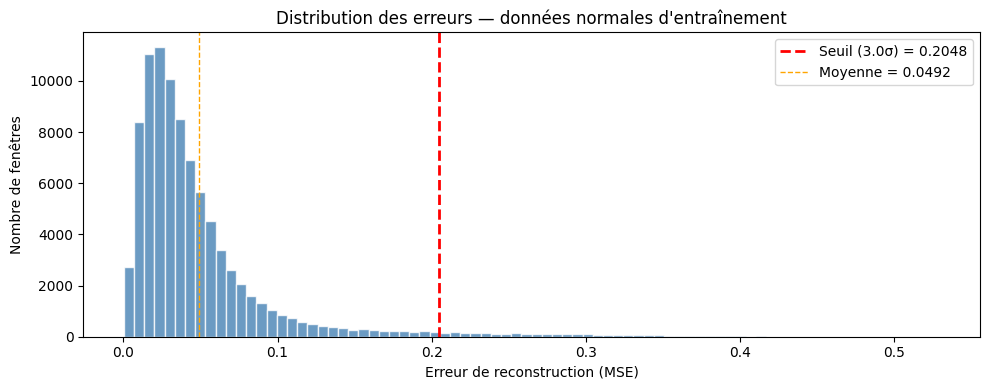

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(threshold, color="red",    linestyle="--", linewidth=2, label=f"Seuil ({K_SIGMA}σ) = {threshold:.4f}")
plt.axvline(mean_err,  color="orange", linestyle="--", linewidth=1, label=f"Moyenne = {mean_err:.4f}")
plt.xlabel("Erreur de reconstruction (MSE)")
plt.ylabel("Nombre de fenêtres")
plt.title("Distribution des erreurs — données normales d'entraînement")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import hls4ml
print(hls4ml.__version__)

1.2.0


In [16]:
import tensorflow as tf
print(tf.__version__)

2.14.0


In [17]:
import json
import numpy as np
from pathlib import Path
import tensorflow as tf
import hls4ml

MODEL_FILE     = Path("autoencoder.h5")
FEATURES_FILE  = Path("features.npy")
HLS_OUTPUT_DIR = Path("hls4ml_output")

# Reuse factors à explorer (plus RF est grand → moins de ressources, plus de latence)
REUSE_FACTORS = [1, 2, 4, 8]

model = tf.keras.models.load_model(MODEL_FILE)
model.summary()

Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 14)]              0         
                                                                 
 dense (Dense)               (None, 8)                 120       
                                                                 
 dense_1 (Dense)             (None, 4)                 36        
                                                                 
 dense_2 (Dense)             (None, 8)                 40        
                                                                 
 dense_3 (Dense)             (None, 14)                126       
                                                                 
Total params: 322 (1.26 KB)
Trainable params: 322 (1.26 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
def convert_model(model, reuse_factor: int, output_dir: Path):
    config = hls4ml.utils.config_from_keras_model(
        model,
        granularity="name",
        default_precision="ap_fixed<16,6>",
        default_reuse_factor=reuse_factor
    )

    print(f"\n── Config RF={reuse_factor} ──")
    for layer_name, layer_cfg in config["LayerName"].items():
        print(f"  {layer_name}: {layer_cfg}")

    hls_model = hls4ml.converters.convert_from_keras_model(
        model,
        hls_config = config,
        output_dir = str(output_dir / f"rf{reuse_factor}"),
        backend    = "VivadoAccelerator",
        board      = "pynq-z2",
        interface  = "axi_stream",
    )

    hls_model.compile()
    return hls_model

In [35]:
hls_models = {}

for rf in REUSE_FACTORS:
    print(f"\n{'='*50}")
    print(f"  Conversion RF={rf}")
    print(f"{'='*50}")
    try:
        hls_m = convert_model(model, rf, HLS_OUTPUT_DIR)
        hls_models[rf] = hls_m
        print(f"[RF={rf}] ✓ Conversion OK")
    except Exception as e:
        print(f"[RF={rf}] ✗ Erreur : {e}")


  Conversion RF=1

── Config RF=1 ──
  input_1: {'Trace': False, 'Precision': {'result': 'auto'}}
  dense: {'Trace': False, 'Precision': {'result': 'auto', 'weight': 'auto', 'bias': 'auto'}}
  dense_relu: {'Trace': False, 'Precision': {'result': 'auto'}}
  dense_1: {'Trace': False, 'Precision': {'result': 'auto', 'weight': 'auto', 'bias': 'auto'}}
  dense_1_relu: {'Trace': False, 'Precision': {'result': 'auto'}}
  dense_2: {'Trace': False, 'Precision': {'result': 'auto', 'weight': 'auto', 'bias': 'auto'}}
  dense_2_relu: {'Trace': False, 'Precision': {'result': 'auto'}}
  dense_3: {'Trace': False, 'Precision': {'result': 'auto', 'weight': 'auto', 'bias': 'auto'}}
  dense_3_linear: {'Trace': False, 'Precision': {'result': 'auto'}}
[RF=1] ✓ Conversion OK

  Conversion RF=2

── Config RF=2 ──
  input_1: {'Trace': False, 'Precision': {'result': 'auto'}}
  dense: {'Trace': False, 'Precision': {'result': 'auto', 'weight': 'auto', 'bias': 'auto'}}
  dense_relu: {'Trace': False, 'Precision': 

In [36]:
features = np.load(FEATURES_FILE)

# Normalise avec le scaler sauvegardé
scaler_params = np.load("scaler.npy")
center = scaler_params[0]
scale  = scaler_params[1]
features_scaled = (features - center) / scale

# Prend un échantillon de 1000 fenêtres pour le test
X_test = features_scaled[:1000].astype(np.float32)

print(f"{'RF':<6} {'MSE keras':>12} {'MSE hls4ml':>12} {'Diff %':>10}")
print("-" * 44)

keras_pred = model.predict(X_test, verbose=0)
keras_mse  = float(np.mean((X_test - keras_pred) ** 2))

for rf, hls_m in hls_models.items():
    hls_pred = hls_m.predict(X_test)
    hls_mse  = float(np.mean((X_test - hls_pred) ** 2))
    diff_pct = abs(hls_mse - keras_mse) / (keras_mse + 1e-10) * 100
    print(f"{rf:<6} {keras_mse:>12.6f} {hls_mse:>12.6f} {diff_pct:>9.2f}%")

RF        MSE keras   MSE hls4ml     Diff %
--------------------------------------------
1          0.048214     0.048817      1.25%
2          0.048214     0.048817      1.25%
4          0.048214     0.048817      1.25%
8          0.048214     0.048817      1.25%


In [41]:
BEST_RF = 4

print(f"Lancement de la synthèse Vivado pour RF={BEST_RF}...")
print("⚠️  Cette étape prend 20-40 minutes, ne ferme pas le notebook.\n")

best_model = hls_models[BEST_RF]
report = best_model.build(
    csim    = False,
    synth   = True,
    export  = True,
)

print("\n── Rapport de synthèse ──")
hls4ml.report.read_vivado_report(
    str(HLS_OUTPUT_DIR / f"rf{BEST_RF}")
)

Lancement de la synthèse Vivado pour RF=4...
⚠️  Cette étape prend 20-40 minutes, ne ferme pas le notebook.


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'moi' on host 'petit-PC-portable.localdomain' (Linux_x86_64 version 6.6.114.1-microsoft-standard-WSL2) on Wed May 27 10:09:16 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/moi/stage/notebooks/hls4ml_output/rf4'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/moi/stage/notebooks/hls4ml_output/rf4/myproject_prj'.
INFO: [HLS 200-10] Adding design file 

In [42]:
hls4ml.report.read_vivado_report(str(HLS_OUTPUT_DIR / f"rf{BEST_RF}"))

Found 1 solution(s) in hls4ml_output/rf4/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vivado HLS Report for 'myproject_axi'
* Date:           Wed May 27 10:12:00 2026

* Version:        2020.1 (Build 2897737 on Wed May 27 20:21:37 MDT 2020)
* Project:        myproject_prj
* Solution:       solution1
* Product family: zynq
* Target device:  xc7z020-clg400-1


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  | 5.00 ns | 4.367 ns |   0.62 ns  |
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+---------+----------+----------

In [40]:
import json
import hls4ml

# Trouve le fichier supported_board.json
import os
hls4ml_path = os.path.dirname(hls4ml.__file__)
board_file  = os.path.join(hls4ml_path, "backends", "vivado_accelerator", "supported_board.json")

with open(board_file) as f:
    boards = json.load(f)

# Affiche ce qui est disponible pour pynq-z2
print(json.dumps(boards.get("pynq-z2", {}), indent=2))

FileNotFoundError: [Errno 2] No such file or directory: '/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/backends/vivado_accelerator/supported_board.json'

In [25]:
import subprocess
result = subprocess.run(
    ["find", hls4ml_path, "-name", "*.json", "-path", "*board*"],
    capture_output=True, text=True
)
print(result.stdout)

# Et aussi cherche tous les json qui parlent de pynq
result2 = subprocess.run(
    ["grep", "-r", "pynq", hls4ml_path, "--include=*.json", "-l"],
    capture_output=True, text=True
)
print(result2.stdout)

/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/backends/vivado_accelerator/supported_boards.json

/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/backends/vivado_accelerator/supported_boards.json



In [26]:
board_file = os.path.join(hls4ml_path, "backends", "vivado_accelerator", "supported_boards.json")

with open(board_file) as f:
    boards = json.load(f)

print(json.dumps(boards.get("pynq-z2", {}), indent=2))

{
  "part": "xc7z020clg400-1",
  "tcl_scripts": {
    "axi_lite": "axi_lite_design.tcl",
    "axi_stream": "axi_stream_design.tcl"
  },
  "python_drivers": {
    "axi_stream": "axi_stream_driver.py"
  },
  "c_drivers": {}
}


In [31]:
import subprocess
result = subprocess.run(
    ["find", 
     "/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/templates/vivado_accelerator/pynq-z2",
     "-type", "f"],
    capture_output=True, text=True
)
print(result.stdout)

/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/templates/vivado_accelerator/pynq-z2/tcl_scripts/axi_lite_design.tcl
/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/templates/vivado_accelerator/pynq-z2/tcl_scripts/axi_stream_design.tcl
/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/templates/vivado_accelerator/pynq-z2/python_drivers/__pycache__/axi_stream_driver.cpython-310.pyc
/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/templates/vivado_accelerator/pynq-z2/python_drivers/axi_stream_driver.py



In [ ]:
best_model.build(
    csim    = False,
    synth   = False,
    export  = False,
    bitfile = True,
)
print("Bitstream généré ✓")


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'moi' on host 'petit-PC-portable.localdomain' (Linux_x86_64 version 6.6.114.1-microsoft-standard-WSL2) on Wed May 27 10:28:55 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/moi/stage/notebooks/hls4ml_output/rf4'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Opening project '/home/moi/stage/notebooks/hls4ml_output/rf4/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmware/myproject_axi.cpp' to the project
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
